# 2D Benchmark Data Generation and Visualization

This notebook automates generating 2D datasets (NPZ bundles) across multiple modalities and offset ranges for few-shot segmentation benchmark evaluation (like UniverSeg).

It produces a clean directory structure:
```text
data/test_data/2d/
  ├─ offset_5/
  │   ├─ 0_hanseg.npz
  │   └─ 0_flare.npz
  └─ offset_10/
      ├─ 0_hanseg.npz
      ...
```

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.test_data.generate_2d_test_data import gen_save_ds
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from data.test_data.ds_handler_2d import load_2d_npz_bundle

2026-04-21 15:08:56.430011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776776936.452550      69 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776776936.459900      69 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776776936.477685      69 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776776936.477734      69 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776776936.477753      69 computation_placer.cc:177] computation placer alr

## 1. Configuration
Define the physical files to load together, the name prefix, and the offset ranges.

In [2]:
# Define dataset groups. Files in the same group are loaded into the same DataLoader.
dataset_groups = [
    {
        "name": "hcc_tase",
        "files": [
            "data/test_data/HCCTase_ceCT.npz"
        ]
    },
    {
        "name": "seg_rap",
        "files": [
            "data/test_data/SegRap2023.npz" 
        ]
    },
]

# Slice offsets to generate datasets for
offsets = [5, 12]

# Generation parameters
num_ds = 100          # Bundles (tasks) to generate per group per offset
max_points = 100     # Target query points per bundle
len_p_set = 16       # Number of support samples

# Base output directory
base_output_dir = project_root / "data" / "test_data" / "2d_hcc_and_seg"

## 2. Generation Loop
Iterate through datasets and offsets to generate all NPZ bundles. <br>
gen_save_ds() loads maximum size quadratic crops and resamples them to 128x128

In [ ]:
for group in dataset_groups:
    ds_name = group["name"]
    files = [str(project_root / f) for f in group["files"]]
    
    print("="*60)
    print(f"Initializing DataLoader for Dataset Group: {ds_name.upper()}")
    print(f"Files: {files}")
    print("="*60)
    
    # Load dataset group into memory
    dl = DataLoader_npz(files, val_size=0.0)
    dg = DataGenerator(dl)
    
    for offset in offsets:
        output_path = base_output_dir / f"offset_{offset}"
        print(f"\n>>> Generating {num_ds} bundles for {ds_name.upper()} with OFFSET {offset} -> {output_path}")
        
        gen_save_ds(
            dg=dg,
            path=str(output_path),
            ds_name=ds_name,
            offset_val=offset,
            num_ds=num_ds,
            max_data_points=max_points,
            len_p_set=len_p_set
        )
        
    # Clear DataLoader to free RAM before next group
    del dl
    del dg
print("\nAll generation completed!")

## 3. Visualization
Randomly load an NPZ bundle and visualize its support set and a few query samples.

In [4]:
from utils.visualization import visualize_bundle

Loaded NPZ bundle: 5_seg_rap.npz
Support Set: sx (z-score)=(16, 128, 128, 1), sy=(16, 128, 128, 1)
Query Set:   x=(100, 128, 128, 1), y=(100, 128, 128, 1), p=(100, 128, 128, 2)


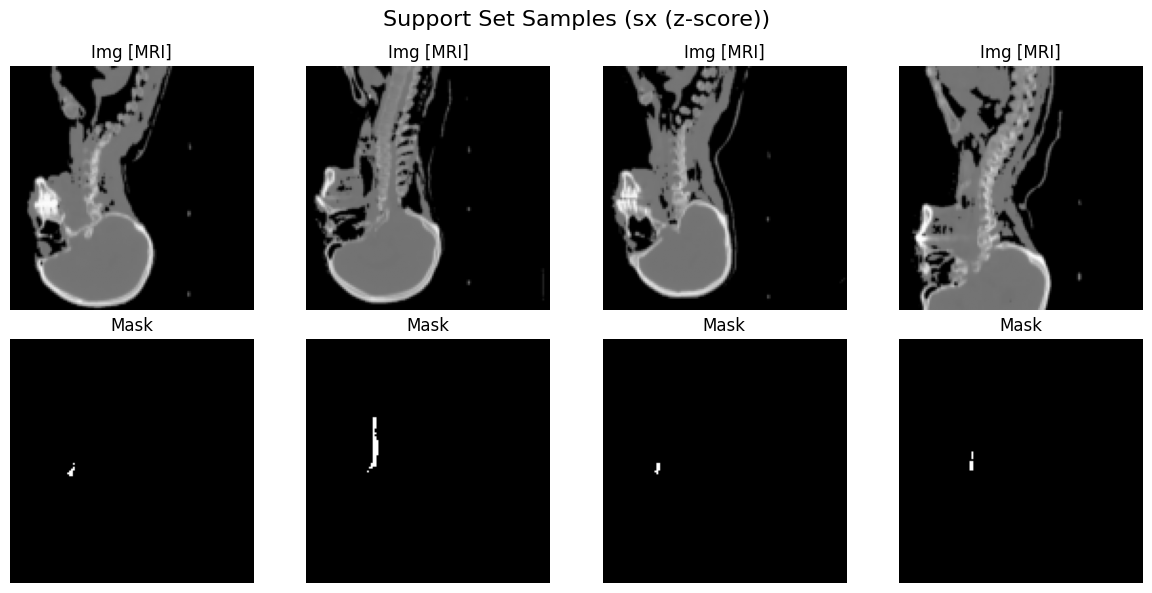

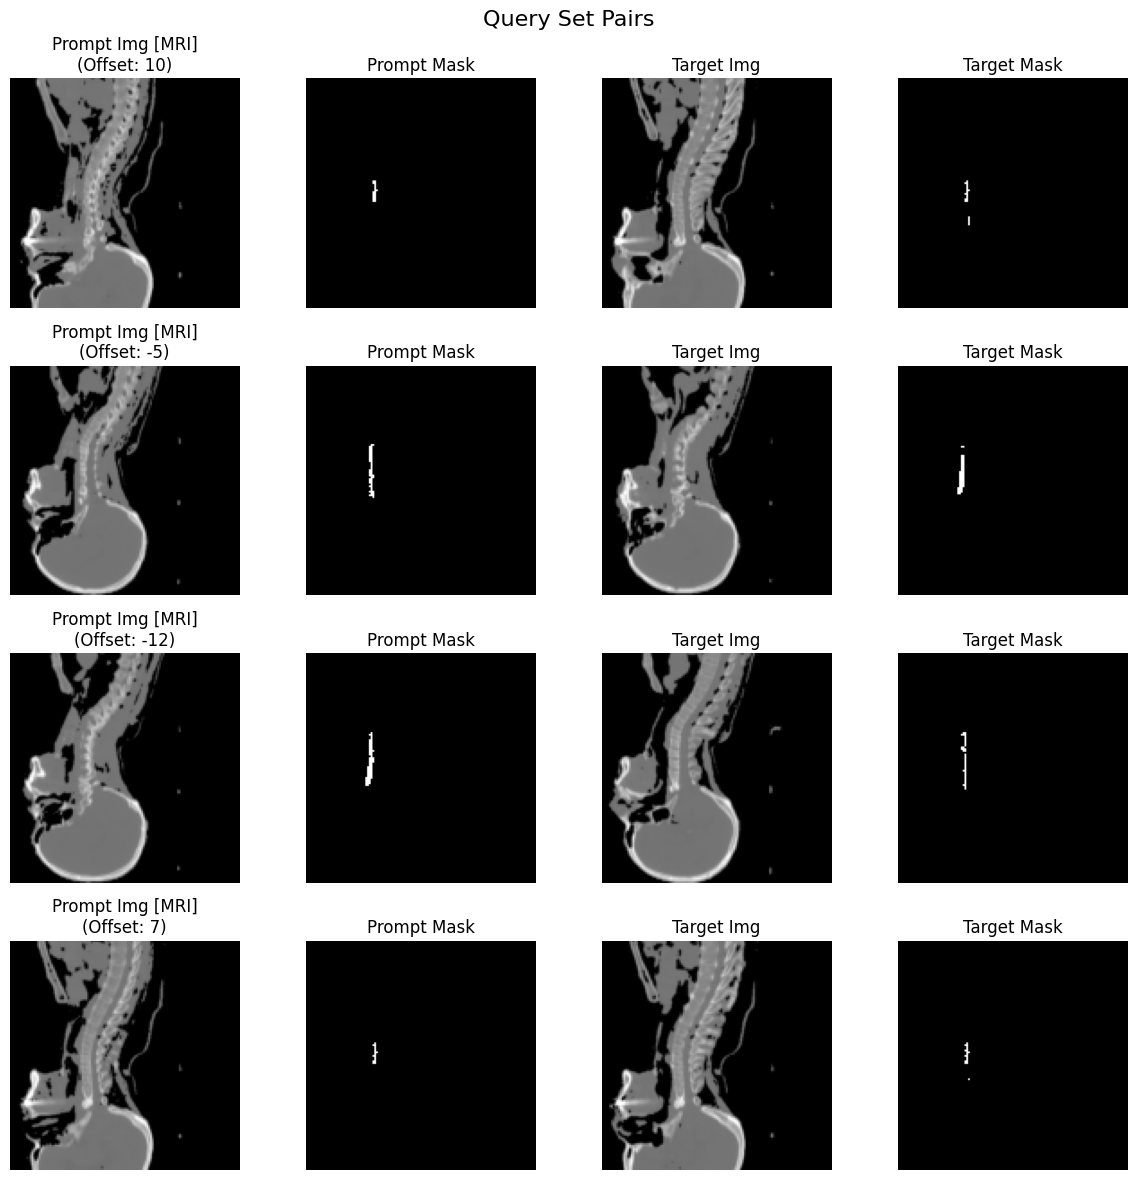

In [13]:
# Example usage: visually inspect one of the newly generated bundles.
import random

offset_to_check = 12
check_dir = base_output_dir / f"offset_{offset_to_check}"

if check_dir.exists():
    npz_files = list(check_dir.glob("*.npz"))
    if npz_files:
        random_file = random.choice(npz_files)
        visualize_bundle(str(random_file))
    else:
        print(f"No .npz files found in {check_dir}")
else:
    print(f"Directory {check_dir} does not exist yet. Run generation first.")